In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [3]:
fund_master = pd.read_csv("data/processed/clean_fund_master.csv")

nav = pd.read_csv("data/processed/clean_nav.csv")

aum = pd.read_csv("data/processed/clean_aum.csv")

sip = pd.read_csv("data/processed/clean_sip_inflows.csv")

category = pd.read_csv("data/processed/clean_category_inflows.csv")

folios = pd.read_csv("data/processed/clean_folio_count.csv")

performance = pd.read_csv("data/processed/clean_performance.csv")

transactions = pd.read_csv("data/processed/clean_transactions.csv")

portfolio = pd.read_csv("data/processed/clean_portfolio_holdings.csv")

benchmark = pd.read_csv("data/processed/clean_benchmark.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folios["month"] = pd.to_datetime(folios["month"])

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(transactions.shape)

(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(32778, 13)


In [6]:
nav_data = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_data.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


### Chart 1: Daily NAV Trend

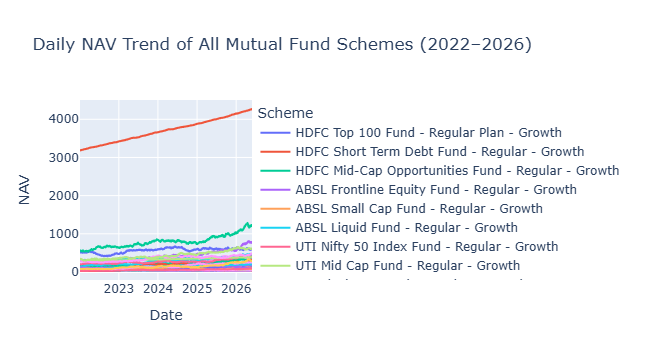

In [7]:
import plotly.express as px

fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme"
)

fig.show()

In [8]:
fig.write_image("reports/nav_trend.png")

In [ ]:
pip install kaleido

### Insight 1

Daily NAV trends show steady long-term growth across most schemes. A noticeable upward movement is visible during the 2023 bull market, while several schemes exhibit temporary declines during the 2024 market correction.

### Chart 2: AUM Growth by Fund House (2022–2025)

In [10]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [11]:
aum["Year"] = aum["date"].dt.year

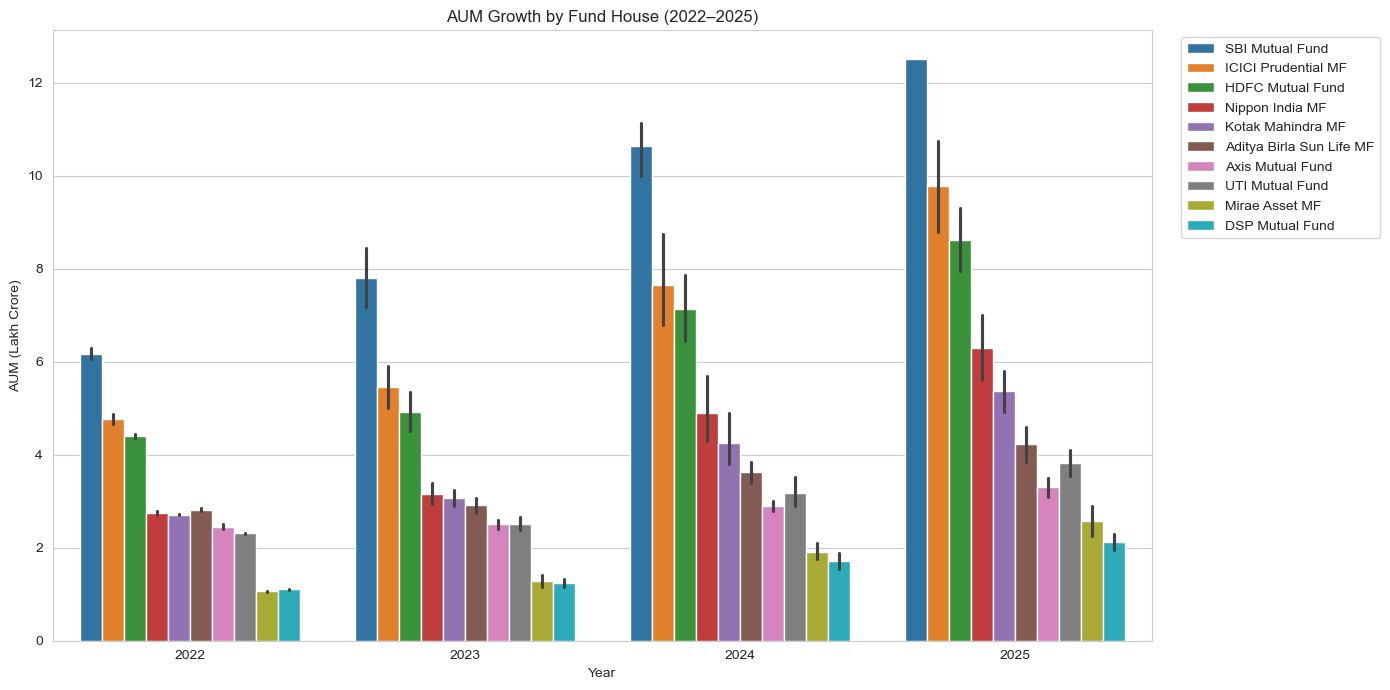

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

In [13]:
plt.savefig("reports/aum_growth.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses, reaching approximately ₹12.5 lakh crore, indicating strong investor confidence and market leadership.

### Chart 3: Monthly SIP Inflow Trend (Plotly)

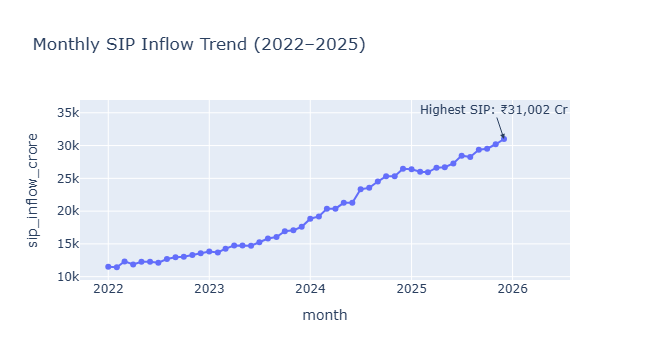

TypeError: Type is not JSON serializable: Timestamp

In [14]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(), "month"],
    y=sip["sip_inflow_crore"].max(),
    text="Highest SIP: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()
fig.write_image("reports/sip_trend.png")

### Insight 3
Monthly SIP inflows showed a steady upward trend, reaching an all-time high of ₹31,002 crore in December 2025.

### Chart 4: Category Inflow Heatmap

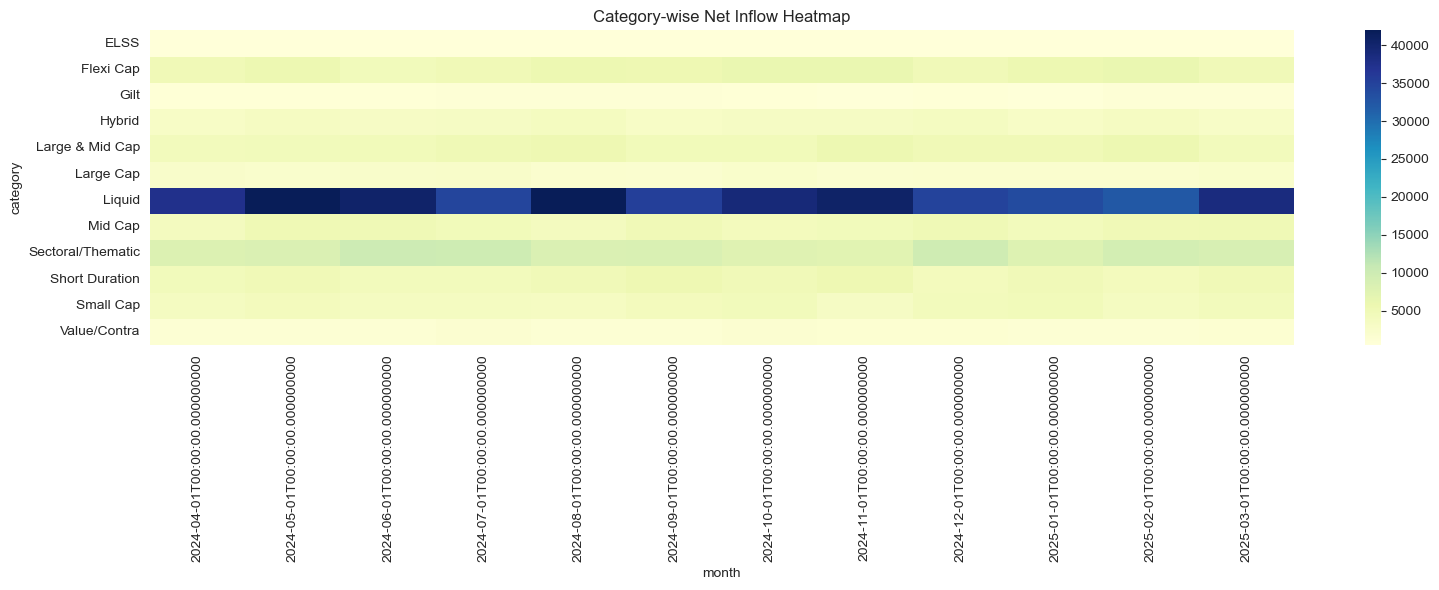

In [15]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Category-wise Net Inflow Heatmap")
plt.tight_layout()
plt.savefig("reports/category_heatmap.png")
plt.show()

### Insight 4
Equity categories attracted consistently higher inflows than debt categories across most months.

### Chart 5: Age Group Distribution


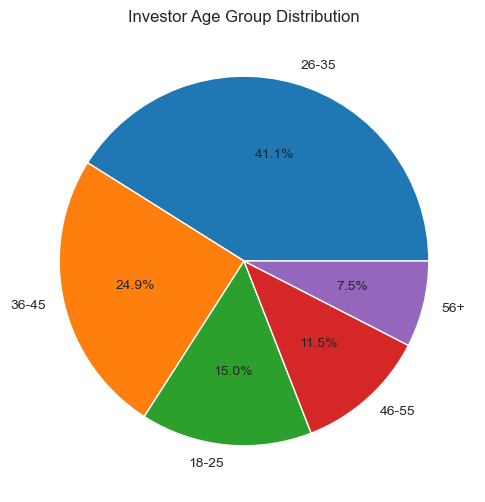

In [17]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.savefig("reports/age_group.png")
plt.show()

### Insight 5
Most mutual fund investors belong to the young and middle-aged population.

### Chart 6: SIP Amount by Age Group

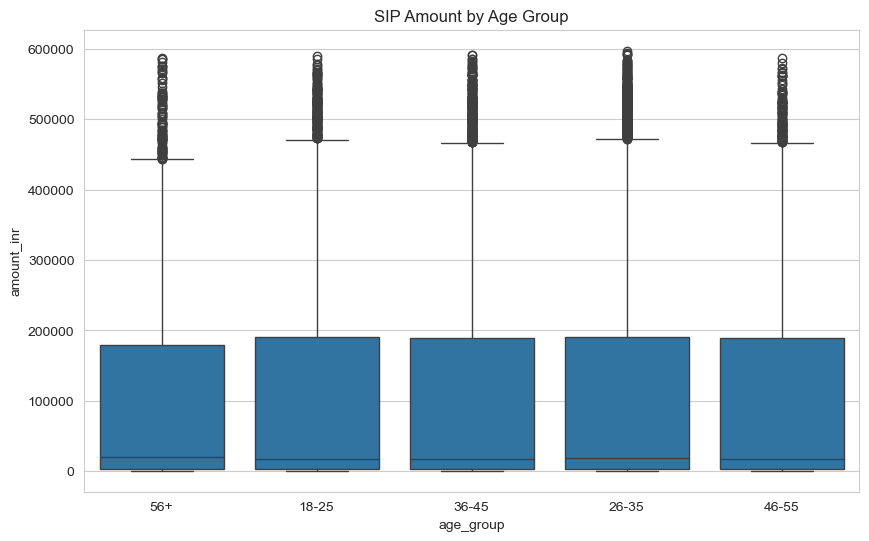

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.savefig("reports/sip_boxplot.png")
plt.show()

## Insight 6
Older investors tend to invest larger amounts compared to younger investors.

## Chart 7: Gender Distribution

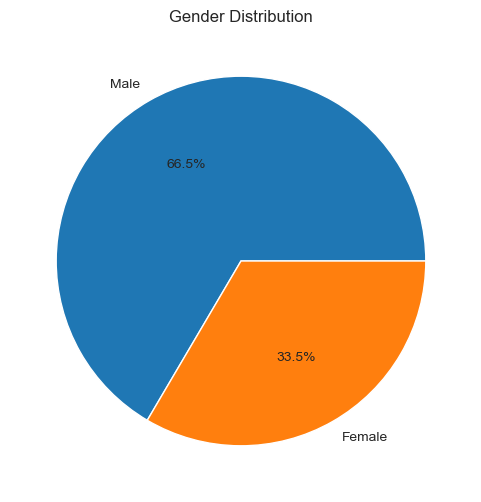

In [19]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.savefig("reports/gender.png")
plt.show()

## Chart 8: SIP Amount by State

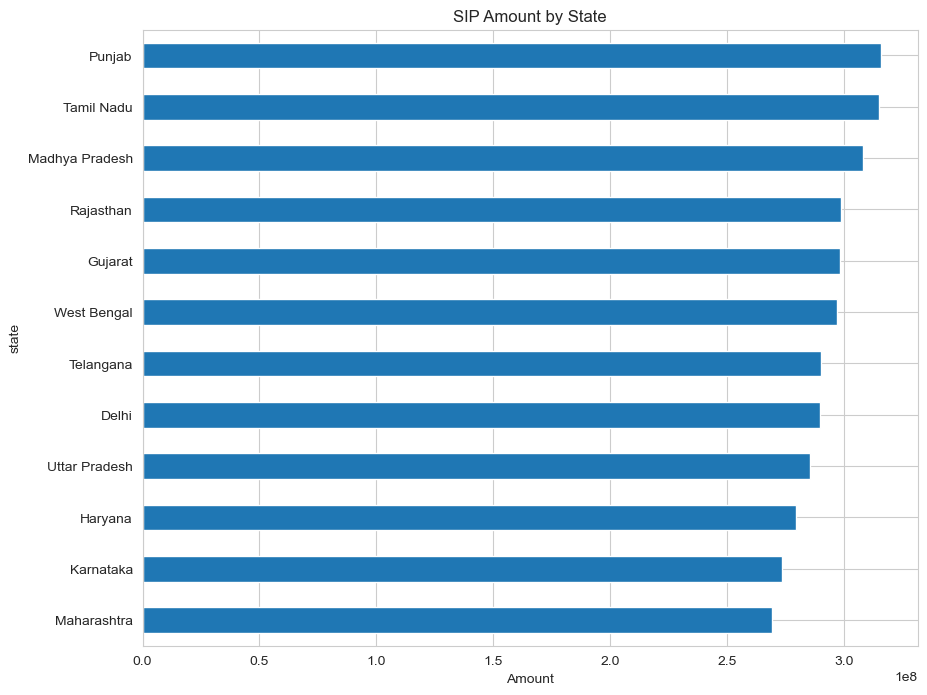

In [20]:
state = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Amount")
plt.savefig("reports/state_sip.png")
plt.show()

## Insight 8
A few major states contribute a significant portion of total SIP investments.

## Chart 9: T30 vs B30

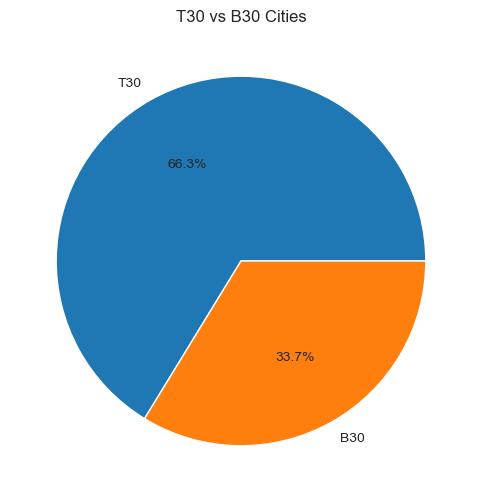

In [21]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("T30 vs B30 Cities")
plt.ylabel("")
plt.savefig("reports/t30_b30.png")
plt.show()

## Insight 9
T30 cities contribute a larger share of investor participation than B30 cities.

## Chart 10: Folio Count Growth

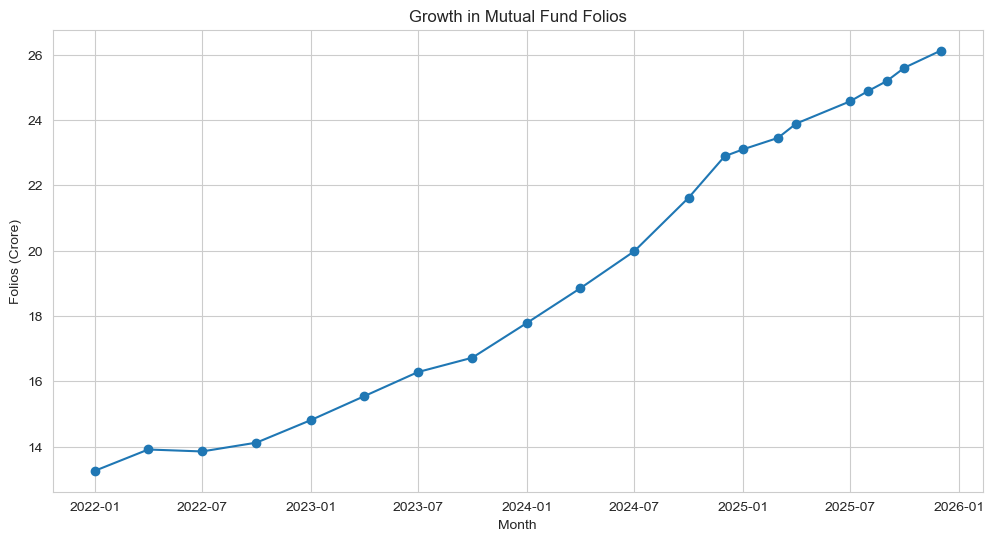

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Mutual Fund Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.savefig("reports/folio_growth.png")
plt.show()

## Insight 10
The number of mutual fund folios nearly doubled between 2022 and 2025.

## Chart 11: Correlation Heatmap

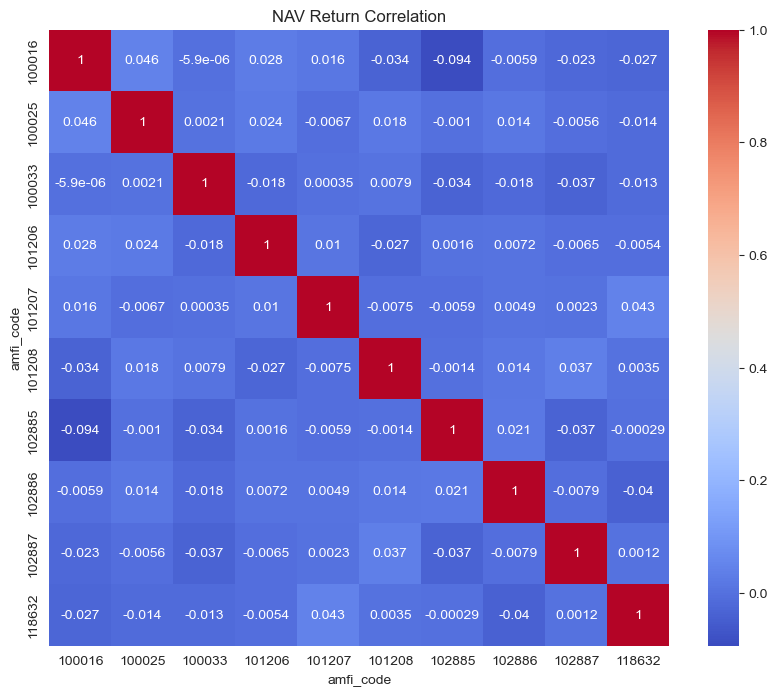

In [23]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")
plt.savefig("reports/correlation.png")
plt.show()

## Chart 12: Sector Allocation Donut

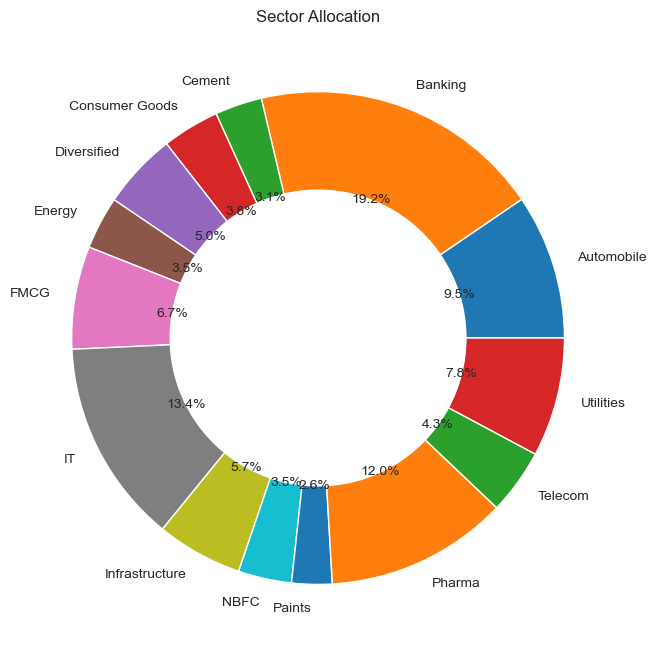

In [24]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")
plt.savefig("reports/sector_allocation.png")
plt.show()

## Chart 13: Risk Category Count

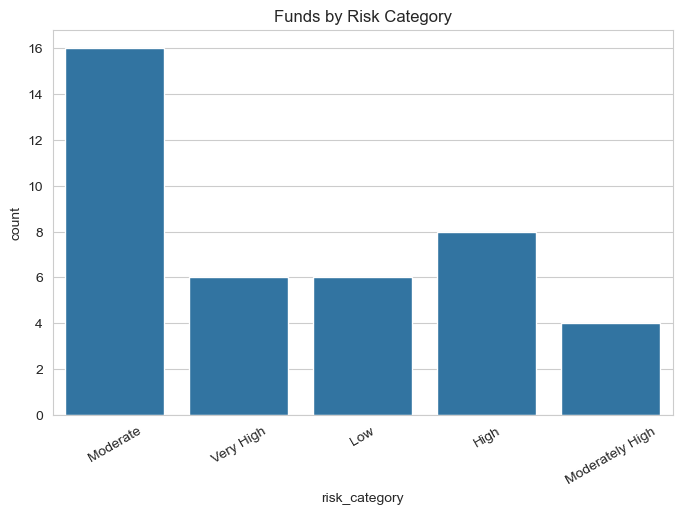

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category"
)

plt.title("Funds by Risk Category")
plt.xticks(rotation=30)

plt.savefig("reports/risk_category.png")
plt.show()

## Chart 14: Expense Ratio Distribution

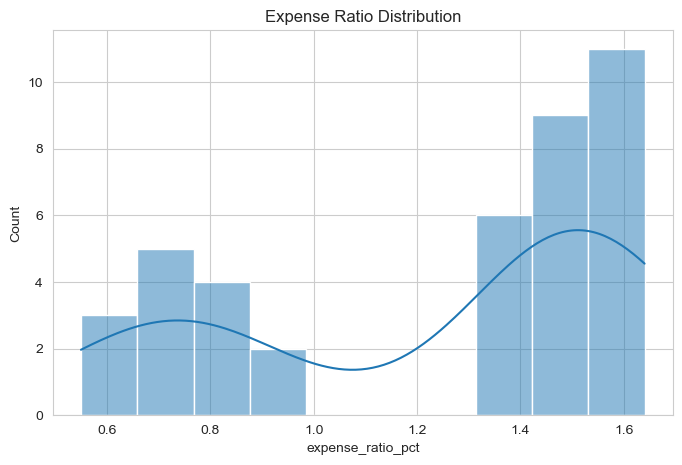

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.savefig("reports/expense_ratio.png")
plt.show()

## Chart 15: AUM Distribution

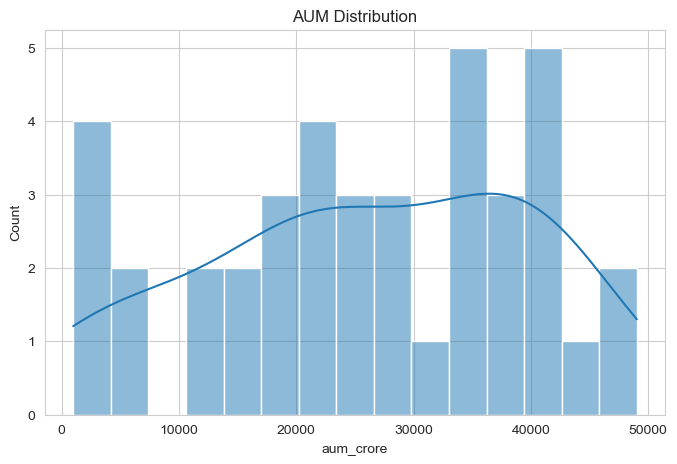

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["aum_crore"],
    bins=15,
    kde=True
)

plt.title("AUM Distribution")
plt.savefig("reports/aum_distribution.png")
plt.show()